In [ ]:
import imfusion as imf
from imfusion import vision # Camera Calibration is in the vision module

import numpy as np
import matplotlib.pyplot as plt


In [8]:
# Load image set
images = imf.load("data/camera_calibration.imf")
# Load marker borad configuration file
# see marker_detection for more details
marker_config = imf.vision.marker_configuration.load_marker("data/camera_calibration_marker_configuration.xml")
# calibration algorithm settings
settings = imf.vision.CameraCalibrationSettings()
settings.fix_radial_distortion = [False, False, True]
settings.min_detections = 10
settings.use_auto_selection = True


Calibration results:
Intrinsic Matrix: [[519.69090477   0.         639.40050464]
 [  0.         519.68387022 479.60405295]
 [  0.           0.           1.        ]]
Distortion Vector: [ 0.00214289 -0.00176578 -0.00108039 -0.00091867  0.        ]
Number of selected images: 20
Selected images: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
MREs: 0.34475162964824224
Standard Deviation of the Intrinsic Matrix: [1.77399549 1.74033052 1.14339299 0.91842164]
Standard Deviation of the Distortion: [0.00228737 0.00228929 0.00052272 0.00065091 0.        ]


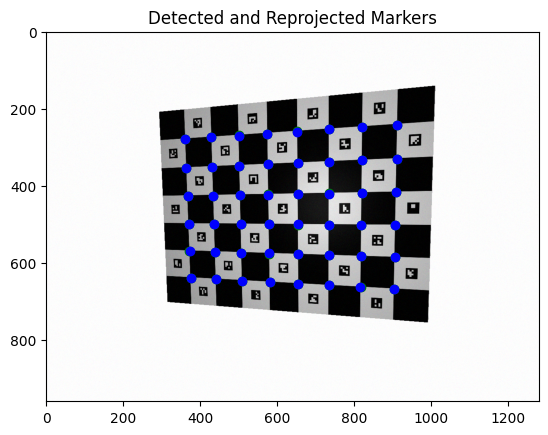


Pose:
  Translation: [-141.70, 97.65, 227.58]
  Rotation matrix:
 [[ 9.86613556e-01 -8.23813056e-03 -1.62867505e-01]
 [ 7.87266249e-04 -9.98470940e-01  5.52735274e-02]
 [-1.63073822e-01 -5.46618315e-02 -9.85098479e-01]]


In [9]:
result = vision.calibrate_camera(images[0], marker_config, settings)

print(f"\nCalibration results:")
print(f"Intrinsic Matrix: {result.intrinsic_matrix}")
print(f"Distortion Vector: {result.distortion_vector}")

print(f"Number of selected images: {len(result.selected_boards)}")
print(f"Selected images: {result.selected_boards}")
print(f"MREs: {result.mre}")
print(f"Standard Deviation of the Intrinsic Matrix: {result.std_intrinsic}")
print(f"Standard Deviation of the Distortion: {result.std_distortion}")

# An example image with detected markers
arr = np.array(images[0][0])
plt.imshow(arr)
# Plot detected image points
for point in result.image_points[0]:
    plt.plot(point[0], point[1], "go")
for point in result.reprojected_image_points[0]:
    plt.plot(point[0], point[1], "bo")
plt.title("Detected and Reprojected Markers")
plt.show()
# An example of camera xtrinsic pose
print(f"\nPose:")
print(f"  Translation: [{result.camera_poses[0][0,3]:.2f}, {result.camera_poses[0][1,3]:.2f}, {result.camera_poses[0][2,3]:.2f}]")
print(f"  Rotation matrix:\n {result.camera_poses[0][:3, :3]}")